# NN-kNN-RL CartPole Demo

This notebook is a thin debugging surface for the repo-native NN-kNN-RL workflow. The implementation lives in `model/nnknn_rl_workflow.py`; this notebook configures runs, calls workflow functions, and visualizes saved artifacts plus retrieved cases.

## Setup

In [1]:
from pathlib import Path
import csv
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import model.nnknn_rl_workflow as nnknn_rl_workflow
nnknn_rl_workflow = importlib.reload(nnknn_rl_workflow)

evaluate_nnknn_rl = nnknn_rl_workflow.evaluate_nnknn_rl
load_nnknn_rl_checkpoint = nnknn_rl_workflow.load_nnknn_rl_checkpoint
make_nnknn_rl_config = nnknn_rl_workflow.make_nnknn_rl_config
train_nnknn_rl = nnknn_rl_workflow.train_nnknn_rl

ROOT

WindowsPath('d:/NN-kNN')

## Choose Run Settings

In [2]:
PROFILE = "fast"  # use "debug" for development or "fast" for the 150k-step comparison budget
SEED = 0
DEVICE = None  # use None for repo default, or set "cpu" / "cuda"

cfg = make_nnknn_rl_config(PROFILE, seed=SEED)
cfg

NNKNNRLConfig(profile='fast', seed=0, total_timesteps=150000, learning_rate=0.0005, case_capacity=10000, max_grad_norm=10.0, min_case_entries=32, eval_frequency=0, eval_episode_frequency=100, eval_episodes=20, eval_seed=10000, success_threshold=475.0, policy_gamma=0.99, policy_update_episodes=4, entropy_coef=0.01, advantage_epsilon=1e-08, advantage_method='reward_to_go', value_function=None, gae_lambda=None, bootstrap_n_steps=None, vtrace=False, nnknn_config={}, use_glocal_weightor=True, glocal_fw_set_num=1, tau=1.0, top_k=10, case_default_bias=0.0, case_bias_l2=0.0001, case_maintenance_frequency=1000, case_prune_quantile=0.05, case_prune_bias_threshold=None, min_cases_per_action=8, source_reference='NN-kNN policy over state-action cases with reward-to-go updates')

## Train NN-kNN-RL

In [3]:
state = train_nnknn_rl("cartpole", cfg, device=DEVICE, progress=True)
summary = state["summary"]
summary

cases trainable: False
labels trainable: False
[nnknn-rl] step=18 episode=1 return=18.0 length=18 loss=None cases=18
[nnknn-rl] step=32 episode=2 return=14.0 length=14 loss=None cases=32
[nnknn-rl] step=76 episode=3 return=44.0 length=44 loss=None cases=76
[nnknn-rl] step=93 episode=4 return=17.0 length=17 loss=0.07472020387649536 cases=93
[nnknn-rl] step=114 episode=5 return=21.0 length=21 loss=None cases=114
[nnknn-rl] step=190 episode=10 return=15.0 length=15 loss=None cases=190
[nnknn-rl] step=362 episode=20 return=13.0 length=13 loss=0.02232242375612259 cases=362
[nnknn-rl] step=548 episode=30 return=37.0 length=37 loss=None cases=548
[nnknn-rl] step=753 episode=40 return=21.0 length=21 loss=0.07490850985050201 cases=753
[nnknn-rl] step=926 episode=50 return=22.0 length=22 loss=None cases=926
[nnknn-rl] step=1111 episode=60 return=11.0 length=11 loss=0.00022987012926023453 cases=1061
[nnknn-rl] step=1357 episode=70 return=20.0 length=20 loss=None cases=1307
[nnknn-rl] step=1623 ep

{'task': 'cartpole',
 'env_id': 'CartPole-v1',
 'profile': 'fast',
 'seed': 0,
 'total_timesteps': 150000,
 'eval_episodes': 20,
 'success_threshold': 475.0,
 'passed': False,
 'advantage_method': 'reward_to_go',
 'final_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 248.6999969482422,
  'std_return': 96.02921295166016,
  'min_return': 107.0,
  'max_return': 500.0,
  'mean_length': 248.6999969482422},
 'last_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 224.5500030517578,
  'std_return': 45.530731201171875,
  'min_return': 162.0,
  'max_return': 339.0,
  'mean_length': 224.5500030517578},
 'selected_step': 148584,
 'selected_source': 'best_eval',
 'training_efficiency': {'best_model_step': 148584,
  'best_model_training_fraction': 0.99056,
  'first_success_step': None,
  'first_success_training_fraction': None,
  'best_minus_last_return': 24.149993896484375,
  'budget_interpretation': 'unsolved_or_underfit'},
 'case_entries': 9789,
 'action_counts': [5101, 4688],

## Inspect Run Artifacts

In [4]:
run_dir = Path(state["run_dir"])
print(run_dir)
for path in sorted(run_dir.iterdir()):
    print(path.name)

with (run_dir / "summary.json").open(encoding="utf-8") as handle:
    saved_summary = json.load(handle)

{
    "selected_step": saved_summary["selected_step"],
    "selected_source": saved_summary["selected_source"],
    "case_entries": saved_summary["case_entries"],
    "final_eval": saved_summary["final_eval"],
    "last_eval": saved_summary["last_eval"],
    "training_efficiency": saved_summary["training_efficiency"],
}

results\rl\nnknn_rl_cartpole_20260619_173139_613526
case_maintenance.csv
checkpoint.pt
config.json
eval_metrics.csv
final_eval_episodes.csv
last_eval_episodes.csv
loss_metrics.csv
manifest.json
summary.json
training_metrics.csv


{'selected_step': 148584,
 'selected_source': 'best_eval',
 'case_entries': 9789,
 'final_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 248.6999969482422,
  'std_return': 96.02921295166016,
  'min_return': 107.0,
  'max_return': 500.0,
  'mean_length': 248.6999969482422},
 'last_eval': {'episodes': 20,
  'seed': 10000,
  'mean_return': 224.5500030517578,
  'std_return': 45.530731201171875,
  'min_return': 162.0,
  'max_return': 339.0,
  'mean_length': 224.5500030517578},
 'training_efficiency': {'best_model_step': 148584,
  'best_model_training_fraction': 0.99056,
  'first_success_step': None,
  'first_success_training_fraction': None,
  'best_minus_last_return': 24.149993896484375,
  'budget_interpretation': 'unsolved_or_underfit'}}

## Plot Training, Evaluation, And Loss

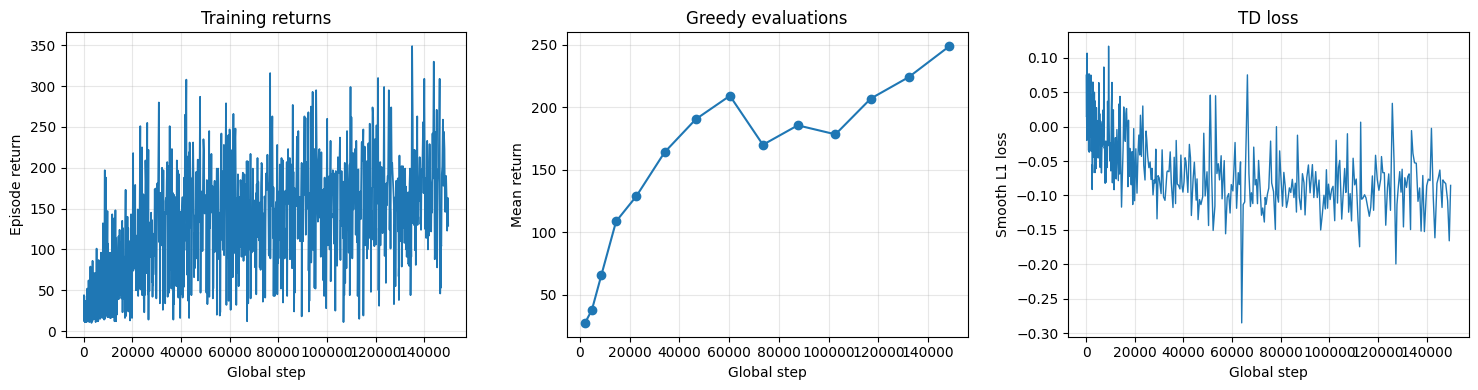

In [5]:
def read_rows(name):
    path = run_dir / name
    if not path.exists() or path.stat().st_size == 0:
        return []
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

training_rows = read_rows("training_metrics.csv")
eval_rows = read_rows("eval_metrics.csv")
loss_rows = read_rows("loss_metrics.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

if training_rows:
    axes[0].plot([int(r["global_step"]) for r in training_rows], [float(r["episode_return"]) for r in training_rows], linewidth=1.25)
axes[0].set_title("Training returns")
axes[0].set_xlabel("Global step")
axes[0].set_ylabel("Episode return")
axes[0].grid(alpha=0.3)

if eval_rows:
    axes[1].plot([int(r["global_step"]) for r in eval_rows], [float(r["mean_return"]) for r in eval_rows], marker="o")
axes[1].set_title("Greedy evaluations")
axes[1].set_xlabel("Global step")
axes[1].set_ylabel("Mean return")
axes[1].grid(alpha=0.3)

if loss_rows:
    axes[2].plot([int(r["global_step"]) for r in loss_rows], [float(r["loss"]) for r in loss_rows], linewidth=1.0)
axes[2].set_title("TD loss")
axes[2].set_xlabel("Global step")
axes[2].set_ylabel("Smooth L1 loss")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Reload Best Checkpoint And Evaluate

In [6]:
if summary["profile"] != PROFILE:
    raise RuntimeError(
        f"The current checkpoint was trained with profile={summary['profile']!r}, "
        f"but PROFILE is now {PROFILE!r}. Rerun Choose Run Settings and Train NN-kNN-RL."
    )

loaded = load_nnknn_rl_checkpoint(state["checkpoint_path"], device=DEVICE)
print(f"Loaded checkpoint: {state['checkpoint_path']}")
print(f"Loaded profile: {loaded['config'].profile}; eval episodes: {loaded['config'].eval_episodes}")
metrics = evaluate_nnknn_rl(
    loaded["task"]["name"],
    loaded["model"],
    episodes=loaded["config"].eval_episodes,
    seed=loaded["config"].eval_seed,
    device=loaded["device"],
)
{key: value for key, value in metrics.items() if key != "episode_metrics"}

cases trainable: False
labels trainable: False
Loaded checkpoint: results\rl\nnknn_rl_cartpole_20260619_173139_613526\checkpoint.pt
Loaded profile: fast; eval episodes: 20


{'episodes': 20,
 'seed': 10000,
 'mean_return': 248.6999969482422,
 'std_return': 96.02921295166016,
 'min_return': 107.0,
 'max_return': 500.0,
 'mean_length': 248.6999969482422}

## Render Policy With Retrieved Cases

In [8]:
import gymnasium as gym
from IPython.display import HTML
from matplotlib import animation
from PIL import Image, ImageDraw, ImageFont

RENDER_MAX_STEPS = 120
RENDER_INTERVAL_MS = 80
PANEL_WIDTH = 520
TOP_K_DISPLAY = 4

model = loaded["model"]
device = loaded["device"]
model.eval()

def _font(size=13):
    try:
        return ImageFont.truetype("DejaVuSans.ttf", size=size)
    except Exception:
        return ImageFont.load_default()

def _action_label(action):
    return "Left" if int(action) == 0 else "Right"

def _draw_state(draw, box, state, title):
    x0, y0, x1, y1 = box
    state = np.asarray(state, dtype=np.float32).reshape(-1)
    draw.rectangle([x0, y0, x1, y1], fill=(252, 252, 252), outline=(205, 205, 205), width=2)
    draw.text((x0 + 8, y0 + 6), title, fill=(25, 25, 25), font=_font(12))
    track_left = x0 + 18
    track_right = x1 - 18
    track_y = y1 - 22
    draw.line([(track_left, track_y), (track_right, track_y)], fill=(120, 120, 120), width=2)
    cart_x = float(np.clip(state[0], -2.4, 2.4))
    theta = float(state[2])
    cart_center = int(track_left + ((cart_x + 2.4) / 4.8) * (track_right - track_left))
    cart_w = 42
    cart_h = 16
    draw.rectangle([cart_center - cart_w // 2, track_y - cart_h, cart_center + cart_w // 2, track_y], fill=(230, 230, 230), outline=(30, 30, 30), width=2)
    pivot = (cart_center, track_y - cart_h)
    pole_len = max(44, int((track_y - y0) * 0.55))
    tip = (int(pivot[0] + pole_len * np.sin(theta)), int(pivot[1] - pole_len * np.cos(theta)))
    draw.line([pivot, tip], fill=(200, 65, 55), width=4)

def _make_cartpole_frame(state, width=500, height=320):
    frame = Image.new("RGB", (width, height), color=(242, 246, 250))
    draw = ImageDraw.Draw(frame)
    draw.text((16, 14), "CartPole policy rollout", fill=(20, 20, 20), font=_font(16))
    _draw_state(draw, (24, 48, width - 24, height - 28), state, "Environment state")
    return np.asarray(frame, dtype=np.uint8)

def _make_panel(height, width, step_idx, obs, action, q_values, explanation):
    panel = Image.new("RGB", (width, height), color=(247, 247, 247))
    draw = ImageDraw.Draw(panel)
    margin = 14
    draw.text((margin, 12), f"NN-kNN retrieved cases | step={step_idx}", fill=(20, 20, 20), font=_font(16))
    draw.text((margin, 36), f"Action: {action} ({_action_label(action)})   Q0={q_values[0]: .2f}  Q1={q_values[1]: .2f}", fill=(35, 35, 35), font=_font(13))
    _draw_state(draw, (margin, 64, width - margin, 178), obs, "Current CartPole state")
    y = 194
    for item in explanation.get("neighbors", [])[:TOP_K_DISPLAY]:
        retrieved = np.asarray(item["observation"], dtype=np.float32)
        draw.text((margin, y), f"#{item['rank']} action={item['action']} ({_action_label(item['action'])})  target={item['value']: .2f}", fill=(20, 20, 20), font=_font(12))
        y += 15
        draw.text((margin, y), f"weight={item['weight']: .3f}  distance={item['distance']: .4f}", fill=(65, 65, 65), font=_font(12))
        y += 15
        if y + 82 < height:
            _draw_state(draw, (margin, y, width - margin, y + 78), retrieved, f"Retrieved state index {item['index']}")
            y += 88
        else:
            break
    return np.asarray(panel, dtype=np.uint8)

env = gym.make(loaded["task"]["env_id"])
obs, _ = env.reset(seed=SEED)
frames = []

try:
    for step_idx in range(RENDER_MAX_STEPS):
        frame = _make_cartpole_frame(obs)
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_tensor = model.q_values(obs_tensor).squeeze(0)
        q_values = [float(value) for value in q_tensor.detach().cpu().tolist()]
        action = int(q_tensor.argmax().item())
        explanation = model.explain(obs, action, k=TOP_K_DISPLAY)
        panel = _make_panel(frame.shape[0], PANEL_WIDTH, step_idx, obs, action, q_values, explanation)
        frames.append(np.concatenate([frame, panel], axis=1))
        obs, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
finally:
    env.close()

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
im = ax.imshow(frames[0])

def update(frame_index):
    im.set_array(frames[frame_index])
    return (im,)

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=RENDER_INTERVAL_MS, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

KeyError: 'value'